# Post-process damping: heave, pitch and roll

This notebook reads the Excel output from:

- `01_calibrate_heave_damping.ipynb`
- `02_calibrate_pitch_roll_damping.ipynb`

It performs one combined analysis for **heave**, **pitch**, and **roll**.

For each DOF, the notebook calculates:

1. the individual **viscous** damping values, i.e. the calibrated values;
2. the individual **total** damping values, where radiation damping is added to the linear damping term;
3. the mean value per construction;
4. the global mean value per DOF.

Four figures are created. Each figure contains three subplots side by side:

1. viscous damping, individual tests only;
2. total damping, individual tests only;
3. viscous damping with the mean per construction and global mean per DOF;
4. total damping with the mean per construction and global mean per DOF.

For the global mean of the total damping, the following method is used:

```python
mean_total_linear = mean_viscous_linear + mean_radiation_damping_of_the_three_constructions
mean_total_quadratic = mean_viscous_quadratic
```

All plots start from `(0, 0)`. The legend order is:

1. Spring with deck
2. Fixed with deck
3. Fixed without deck

In [5]:
# ============================================================
# Imports
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [6]:
# ============================================================
# Input/output paths and plot settings
# ============================================================
# Adjust these paths if your output folders have different names.
heave_output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2")
pitch_roll_output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2")

# Excel files created by the calibration notebooks.
heave_excel_path = heave_output_dir / "calibrated_heave_decay_coefficients.xlsx"
pitch_roll_excel_path = pitch_roll_output_dir / "calibrated_pitch_roll_decay_coefficients.xlsx"

# Output folder for this post-processing notebook.
summary_dir = heave_output_dir / "damping_summary_all_dofs"
summary_dir.mkdir(parents=True, exist_ok=True)

summary_excel_path = summary_dir / "damping_summary_all_dofs.xlsx"

plot_viscous_individual_path = summary_dir / "01_viscous_damping_individual_all_dofs.png"
plot_total_individual_path = summary_dir / "02_total_damping_individual_all_dofs.png"
plot_viscous_with_means_path = summary_dir / "03_viscous_damping_with_means_all_dofs.png"
plot_total_with_means_path = summary_dir / "04_total_damping_with_means_all_dofs.png"

TITLE_SIZE = 16 + 5
LABEL_SIZE = 14 + 3
TICK_SIZE = 12 + 5

# Subplot order.
DOF_ORDER = ["heave", "pitch", "roll"]

# Construction order used for sorting and for the legend.
CONSTRUCTION_ORDER = ["spring", "fixedwith", "fixedwithout"]

# Display names used in plots and printed output.
CONSTRUCTION_LABELS = {
    "spring": "Spring with deck",
    "fixedwith": "Fixed with deck",
    "fixedwithout": "Fixed without deck",
}

DOF_LABELS = {
    "heave": "Heave",
    "pitch": "Pitch",
    "roll": "Roll",
}

# Radiation damping map.
# For each DOF, only the matching value is used.
rad_damping_map = {
    ("fixedwith", "pitch"): 142.78,
    ("fixedwith", "roll"): 142.78,
    ("fixedwith", "heave"): 3.05,

    ("fixedwithout", "pitch"): 176.24,
    ("fixedwithout", "roll"): 176.24,
    ("fixedwithout", "heave"): 4.00,

    ("spring", "pitch"): 88.35,
    ("spring", "roll"): 82.50,
    ("spring", "heave"): 2.23,
}

print(f"Heave input Excel:      {heave_excel_path}")
print(f"Pitch/roll input Excel: {pitch_roll_excel_path}")
print(f"Output folder:          {summary_dir}")

Heave input Excel:      C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\calibrated_heave_decay_coefficients.xlsx
Pitch/roll input Excel: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\calibrated_pitch_roll_decay_coefficients.xlsx
Output folder:          C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs


In [7]:
# ============================================================
# Helper functions for reading and cleaning data
# ============================================================
def normalize_text(series):
    return series.astype(str).str.strip().str.lower()


def read_dof_results(excel_path: Path, sheet_name: str, dof: str) -> pd.DataFrame:
    """
    Read one DOF sheet and make the columns consistent.
    Expected minimum columns:
        construction, linear_damping, quadratic_damping
    """
    df = pd.read_excel(excel_path, sheet_name=sheet_name)
    df = df.copy()

    if "dof" in df.columns:
        df["dof"] = normalize_text(df["dof"])
        df = df[df["dof"] == dof].copy()
    else:
        df["dof"] = dof

    required_columns = ["construction", "linear_damping", "quadratic_damping"]
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(
            f"These columns are missing in {excel_path.name}, sheet '{sheet_name}': "
            + ", ".join(missing)
        )

    df["construction"] = normalize_text(df["construction"])
    df["dof"] = normalize_text(df["dof"])
    df["linear_damping"] = pd.to_numeric(df["linear_damping"], errors="coerce")
    df["quadratic_damping"] = pd.to_numeric(df["quadratic_damping"], errors="coerce")

    df = df.dropna(subset=["construction", "dof", "linear_damping", "quadratic_damping"]).copy()

    # Radiation damping is added to the linear viscous damping term.
    df["radiation_damping"] = df.apply(
        lambda row: rad_damping_map.get((row["construction"], row["dof"]), 0.0),
        axis=1,
    )
    df["total_linear_damping"] = df["linear_damping"] + df["radiation_damping"]
    df["total_quadratic_damping"] = df["quadratic_damping"]

    # Sorting for tables and plots.
    df["dof"] = pd.Categorical(df["dof"], categories=DOF_ORDER, ordered=True)
    df["construction"] = pd.Categorical(
        df["construction"], categories=CONSTRUCTION_ORDER, ordered=True
    )
    df = df.sort_values(["dof", "construction"]).copy()

    # Convert back to text to keep groupby/export output readable.
    df["dof"] = df["dof"].astype(str)
    df["construction"] = df["construction"].astype(str)
    return df

In [8]:
# ============================================================
# Read results: heave, pitch and roll
# ============================================================
heave_df = read_dof_results(heave_excel_path, sheet_name="heave", dof="heave")
pitch_df = read_dof_results(pitch_roll_excel_path, sheet_name="pitch", dof="pitch")
roll_df = read_dof_results(pitch_roll_excel_path, sheet_name="roll", dof="roll")

df_valid = pd.concat([heave_df, pitch_df, roll_df], ignore_index=True)

print(f"Total number of valid results: {len(df_valid)}")
print(df_valid.groupby(["dof", "construction"]).size())

display_columns = [
    col for col in [
        "dof", "construction", "file_name",
        "linear_damping", "quadratic_damping",
        "radiation_damping",
        "total_linear_damping", "total_quadratic_damping",
    ]
    if col in df_valid.columns
]
display(df_valid[display_columns].head(30))

BadZipFile: File is not a zip file

In [ ]:
# ============================================================
# Mean per construction and DOF
# ============================================================
construction_summary = (
    df_valid
    .groupby(["dof", "construction"], as_index=False)
    .agg(
        n=("linear_damping", "size"),

        mean_viscous_linear_damping=("linear_damping", "mean"),
        mean_viscous_quadratic_damping=("quadratic_damping", "mean"),
        std_viscous_linear_damping=("linear_damping", "std"),
        std_viscous_quadratic_damping=("quadratic_damping", "std"),

        radiation_damping=("radiation_damping", "first"),

        mean_total_linear_damping=("total_linear_damping", "mean"),
        mean_total_quadratic_damping=("total_quadratic_damping", "mean"),
        std_total_linear_damping=("total_linear_damping", "std"),
        std_total_quadratic_damping=("total_quadratic_damping", "std"),
    )
)

construction_summary["dof"] = pd.Categorical(
    construction_summary["dof"], categories=DOF_ORDER, ordered=True
)
construction_summary["construction"] = pd.Categorical(
    construction_summary["construction"], categories=CONSTRUCTION_ORDER, ordered=True
)
construction_summary = construction_summary.sort_values(["dof", "construction"]).copy()
construction_summary["dof"] = construction_summary["dof"].astype(str)
construction_summary["construction"] = construction_summary["construction"].astype(str)
construction_summary["construction_label"] = construction_summary["construction"].map(CONSTRUCTION_LABELS)

display(construction_summary)

,dof,construction,n,mean_viscous_linear_damping,mean_viscous_quadratic_damping,std_viscous_linear_damping,std_viscous_quadratic_damping,radiation_damping,mean_total_linear_damping,mean_total_quadratic_damping,std_total_linear_damping,std_total_quadratic_damping,construction_label
2,heave,spring,4,4.562500,2.750000,1.897092,1.020621,2.23,6.792500,2.750000,1.897092,1.020621,Spring with deck
0,heave,fixedwith,4,4.437500,2.937500,1.663017,1.712394,3.05,7.487500,2.937500,1.663017,1.712394,Fixed with deck
1,heave,fixedwithout,4,0.812500,1.375000,1.068000,0.877971,4.00,4.812500,1.375000,1.068000,0.877971,Fixed without deck
5,pitch,spring,3,330.000000,77.777778,5.773503,134.715063,88.35,418.350000,77.777778,5.773503,134.715063,Spring with deck
3,pitch,fixedwith,3,277.777778,527.777778,71.827984,647.287789,142.78,420.557778,527.777778,71.827984,647.287789,Fixed with deck
4,pitch,fixedwithout,4,164.166667,1145.833333,9.574271,218.740079,176.24,340.406667,1145.833333,9.574271,218.740079,Fixed without deck
8,roll,spring,4,298.333333,112.500000,30.000000,160.078106,82.50,380.833333,112.500000,30.000000,160.078106,Spring with deck
6,roll,fixedwith,3,247.777778,583.333333,64.750232,680.685929,142.78,390.557778,583.333333,64.750232,680.685929,Fixed with deck
7,roll,fixedwithout,4,129.166667,287.500000,37.749172,188.745861,176.24,305.406667,287.500000,37.749172,188.745861,Fixed without deck


In [ ]:
# ============================================================
# Global means per DOF
# ============================================================
# For viscous damping: mean over all individual tests per DOF.
# For total damping: global viscous mean + mean radiation damping of the three constructions per DOF.
# The quadratic value is not changed by radiation damping.
rows = []
for dof in DOF_ORDER:
    df_dof = df_valid[df_valid["dof"] == dof].copy()

    mean_viscous_linear = df_dof["linear_damping"].mean()
    mean_viscous_quadratic = df_dof["quadratic_damping"].mean()

    mean_radiation_from_constructions = np.mean([
        rad_damping_map.get((construction, dof), 0.0)
        for construction in CONSTRUCTION_ORDER
    ])

    rows.append({
        "dof": dof,
        "method": "mean_of_all_individual_tests",
        "n": len(df_dof),
        "viscous_linear_damping": mean_viscous_linear,
        "viscous_quadratic_damping": mean_viscous_quadratic,
        "mean_radiation_damping_of_constructions": mean_radiation_from_constructions,
        "total_linear_damping": mean_viscous_linear + mean_radiation_from_constructions,
        "total_quadratic_damping": mean_viscous_quadratic,
    })

overall_summary = pd.DataFrame(rows)
overall_summary["dof"] = pd.Categorical(overall_summary["dof"], categories=DOF_ORDER, ordered=True)
overall_summary = overall_summary.sort_values("dof").copy()
overall_summary["dof"] = overall_summary["dof"].astype(str)

display(overall_summary)

,dof,method,n,viscous_linear_damping,viscous_quadratic_damping,mean_radiation_damping_of_constructions,total_linear_damping,total_quadratic_damping
0,heave,mean_of_all_individual_tests,12,3.270833,2.354167,3.093333,6.364167,2.354167
1,pitch,mean_of_all_individual_tests,10,248.000000,640.000000,135.790000,383.790000,640.000000
2,roll,mean_of_all_individual_tests,11,223.030303,304.545455,133.840000,356.870303,304.545455


In [ ]:
# ============================================================
# Export summary to Excel
# ============================================================
with pd.ExcelWriter(summary_excel_path, engine="openpyxl") as writer:
    df_valid.to_excel(writer, sheet_name="individual_results_all_dofs", index=False)
    construction_summary.to_excel(writer, sheet_name="mean_per_construction_dof", index=False)
    overall_summary.to_excel(writer, sheet_name="overall_mean_per_dof", index=False)

print(f"Summary saved to:\n{summary_excel_path}")

Summary saved to:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_summary_all_dofs.xlsx


In [ ]:
# ============================================================
# Plot helpers
# ============================================================
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
construction_colors = {
    "spring": color_cycle[0],
    "fixedwith": color_cycle[1],
    "fixedwithout": color_cycle[2],
}


def get_axis_labels(dof: str, damping_type: str):
    """Create axis labels per DOF and damping type."""
    prefix = "Viscous" if damping_type == "viscous" else "Total"

    if dof == "heave":
        return (
            f"{prefix} linear damping [kN/(m/s)]",
            f"{prefix} quadratic damping [kN/(m/s)^2]",
        )
    else:
        return (
            f"{prefix} linear damping [kNm/(rad/s)]",
            f"{prefix} quadratic damping [kNm/(rad/s)^2]",
        )


def get_global_row(dof: str, method: str = "mean_of_all_individual_tests"):
    row = overall_summary[
        (overall_summary["dof"] == dof)
        & (overall_summary["method"] == method)
    ]
    if row.empty:
        raise ValueError(f"No global mean found for dof={dof}, method={method}")
    return row.iloc[0]


def apply_axis_format(ax, dof, damping_type):
    xlabel, ylabel = get_axis_labels(dof, damping_type)
    ax.set_title(DOF_LABELS[dof], fontsize=TITLE_SIZE)
    ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.25)

    # Every plot starts from the origin.
    if dof == "roll" or dof == "pitch":
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=-50)
    else:
        ax.set_xlim(left=-0.2)
        ax.set_ylim(bottom=0)


def plot_all_dofs(
    x_col,
    y_col,
    damping_type,
    fig_title,
    save_path,
    include_means=False,
    mean_x_col=None,
    mean_y_col=None,
    global_x_col=None,
    global_y_col=None,
):
    # Wider and taller figure for better readability.
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=False, sharey=False)

    for ax, dof in zip(axes, DOF_ORDER):
        df_dof = df_valid[df_valid["dof"] == dof]
        summary_dof = construction_summary[construction_summary["dof"] == dof]

        # Individual tests per construction.
        for construction in CONSTRUCTION_ORDER:
            group = df_dof[df_dof["construction"] == construction]
            if group.empty:
                continue
            ax.scatter(
                group[x_col],
                group[y_col],
                s=80,
                alpha=0.75,
                color=construction_colors[construction],
                edgecolors="none",
                label=CONSTRUCTION_LABELS[construction],
            )

        if include_means:
            if mean_x_col is None or mean_y_col is None or global_x_col is None or global_y_col is None:
                raise ValueError("For include_means=True, mean and global columns must be provided.")

            # Mean per construction as an X marker in the same color as the individual tests.
            for construction in CONSTRUCTION_ORDER:
                row = summary_dof[summary_dof["construction"] == construction]
                if row.empty:
                    continue
                row = row.iloc[0]
                ax.scatter(
                    row[mean_x_col],
                    row[mean_y_col],
                    s=220,
                    marker="X",
                    color=construction_colors[construction],
                    edgecolors="none",
                    linewidths=0,
                    label=f"{CONSTRUCTION_LABELS[construction]} - mean",
                )

            # Global mean per DOF in black.
            global_row = get_global_row(dof, method="mean_of_all_individual_tests")
            ax.scatter(
                global_row[global_x_col],
                global_row[global_y_col],
                s=300,
                marker="X",
                color="black",
                edgecolors="none",
                linewidths=0,
                label="Global mean",
            )

        apply_axis_format(ax, dof, damping_type)

    # One shared legend for the complete figure.
    if include_means:
        handles = []
        labels = []
        for construction in CONSTRUCTION_ORDER:
            label = CONSTRUCTION_LABELS[construction]
            color = construction_colors[construction]
            handles.append(Line2D([0], [0], marker="o", linestyle="None", color=color, markersize=10))
            labels.append(f"{label} - individual")
            handles.append(Line2D([0], [0], marker="X", linestyle="None", color=color, markersize=12))
            labels.append(f"{label} - mean")
        handles.append(Line2D([0], [0], marker="X", linestyle="None", color="black", markersize=14))
        labels.append("Global mean per DOF")
    else:
        handles = [
            Line2D([0], [0], marker="o", linestyle="None", color=construction_colors[c], markersize=8)
            for c in CONSTRUCTION_ORDER
        ]
        labels = [CONSTRUCTION_LABELS[c] for c in CONSTRUCTION_ORDER]

    fig.suptitle(fig_title, fontsize=TITLE_SIZE + 2)
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=11 + 6, frameon=False)
    fig.tight_layout(rect=[0, 0.13, 1, 0.93])
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Plot saved to:\n{save_path}")

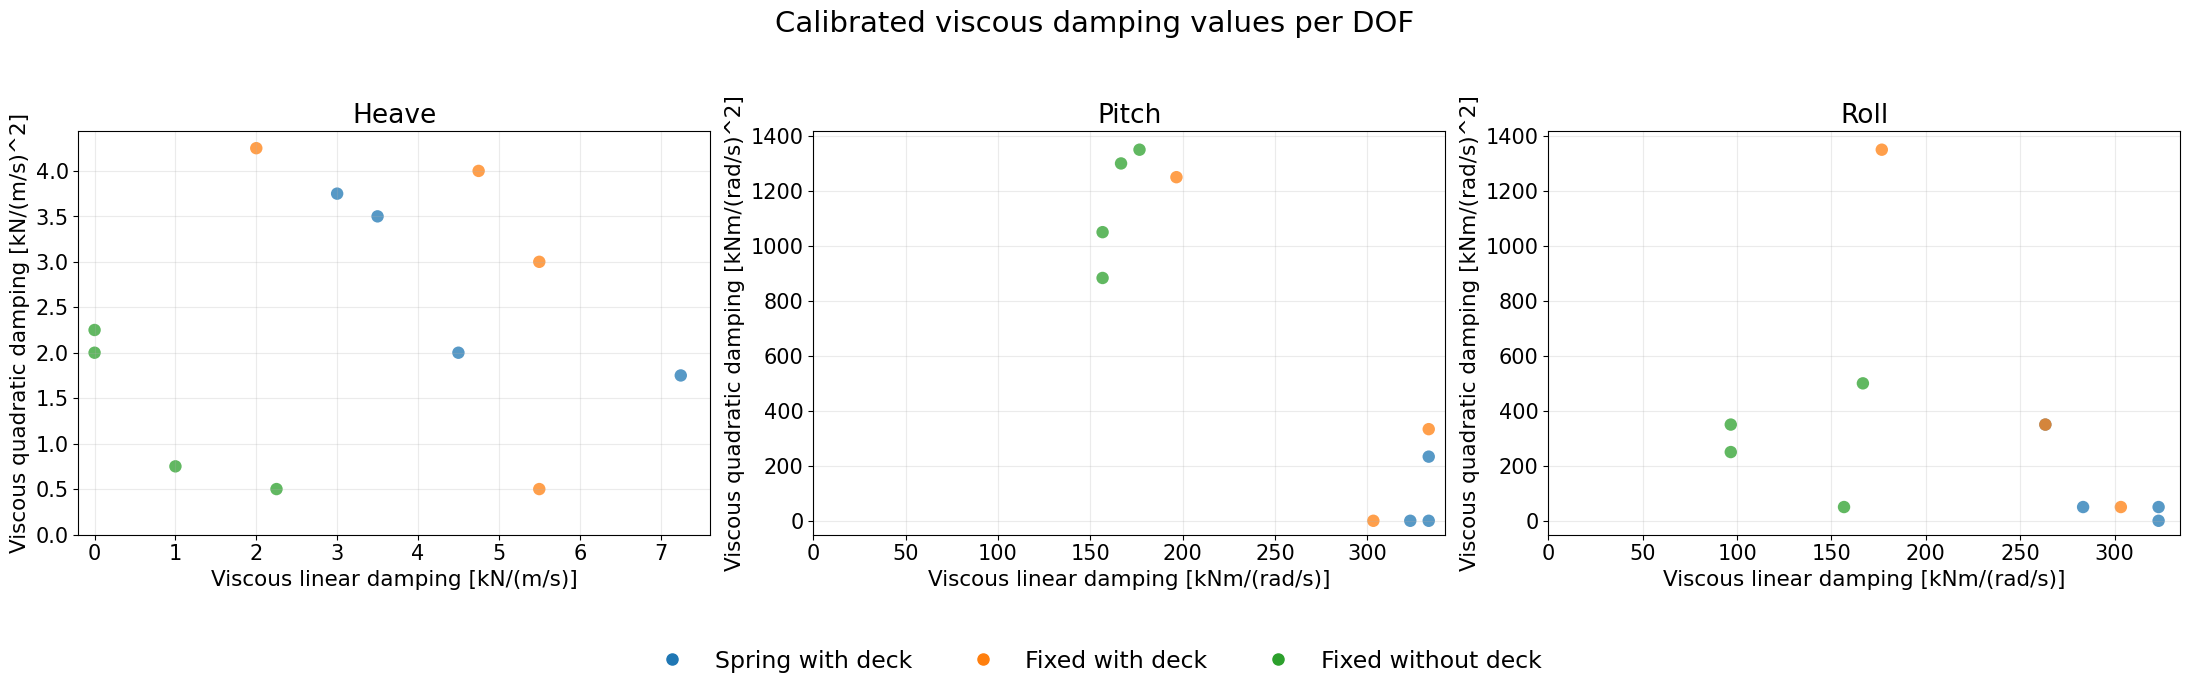

Plot saved to:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\01_viscous_damping_individual_all_dofs.png


In [ ]:
# ============================================================
# Plot 1: viscous individual damping values only
# ============================================================
plot_all_dofs(
    x_col="linear_damping",
    y_col="quadratic_damping",
    damping_type="viscous",
    fig_title="Calibrated viscous damping values per DOF",
    save_path=plot_viscous_individual_path,
    include_means=False,
)

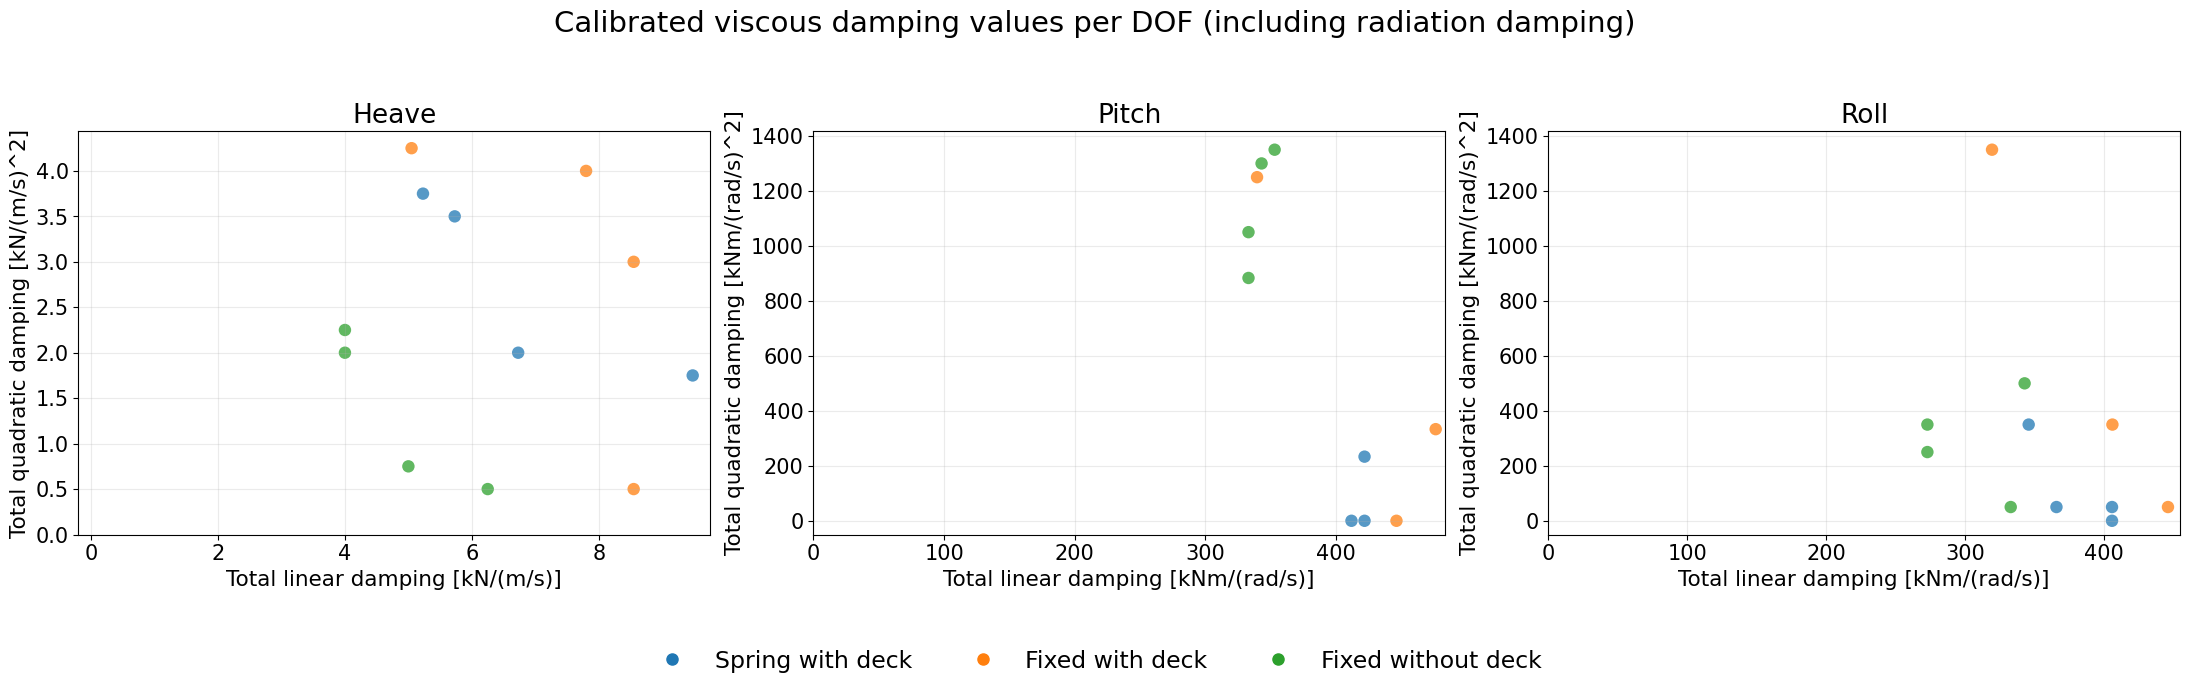

Plot saved to:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\02_total_damping_individual_all_dofs.png


In [ ]:
# ============================================================
# Plot 2: total individual damping values only
# ============================================================
plot_all_dofs(
    x_col="total_linear_damping",
    y_col="total_quadratic_damping",
    damping_type="total",
    fig_title="Calibrated viscous damping values per DOF (including radiation damping)",
    save_path=plot_total_individual_path,
    include_means=False,
)

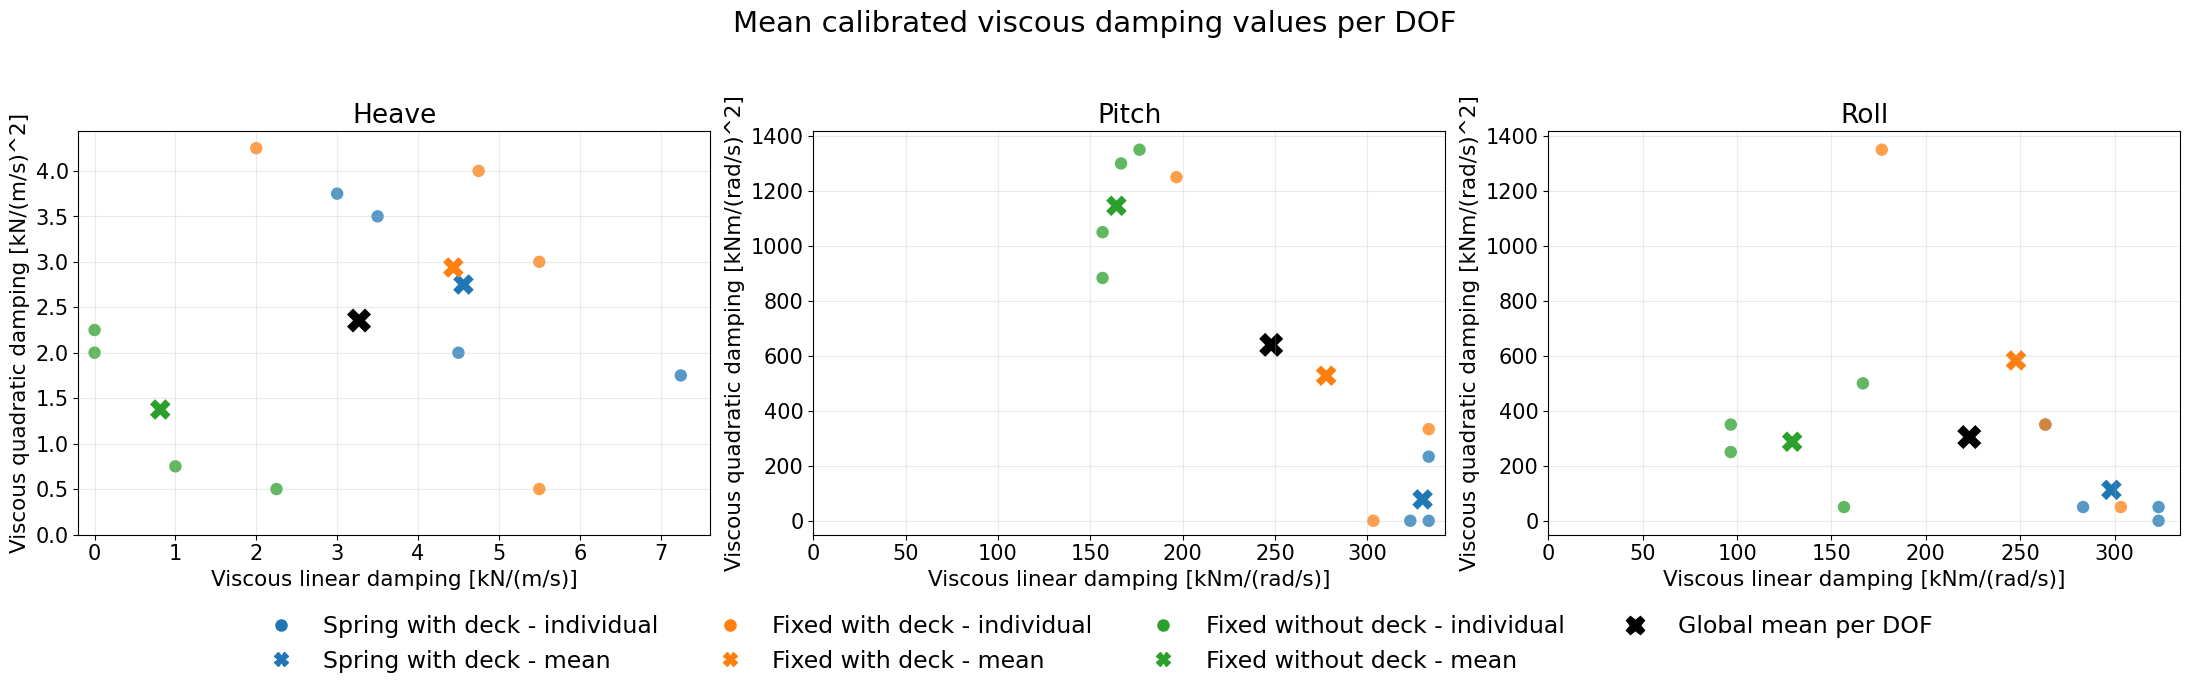

Plot saved to:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\03_viscous_damping_with_means_all_dofs.png


In [ ]:
# ============================================================
# Plot 3: viscous damping with mean per construction and global mean per DOF
# ============================================================
plot_all_dofs(
    x_col="linear_damping",
    y_col="quadratic_damping",
    damping_type="viscous",
    fig_title="Mean calibrated viscous damping values per DOF",
    save_path=plot_viscous_with_means_path,
    include_means=True,
    mean_x_col="mean_viscous_linear_damping",
    mean_y_col="mean_viscous_quadratic_damping",
    global_x_col="viscous_linear_damping",
    global_y_col="viscous_quadratic_damping",
)

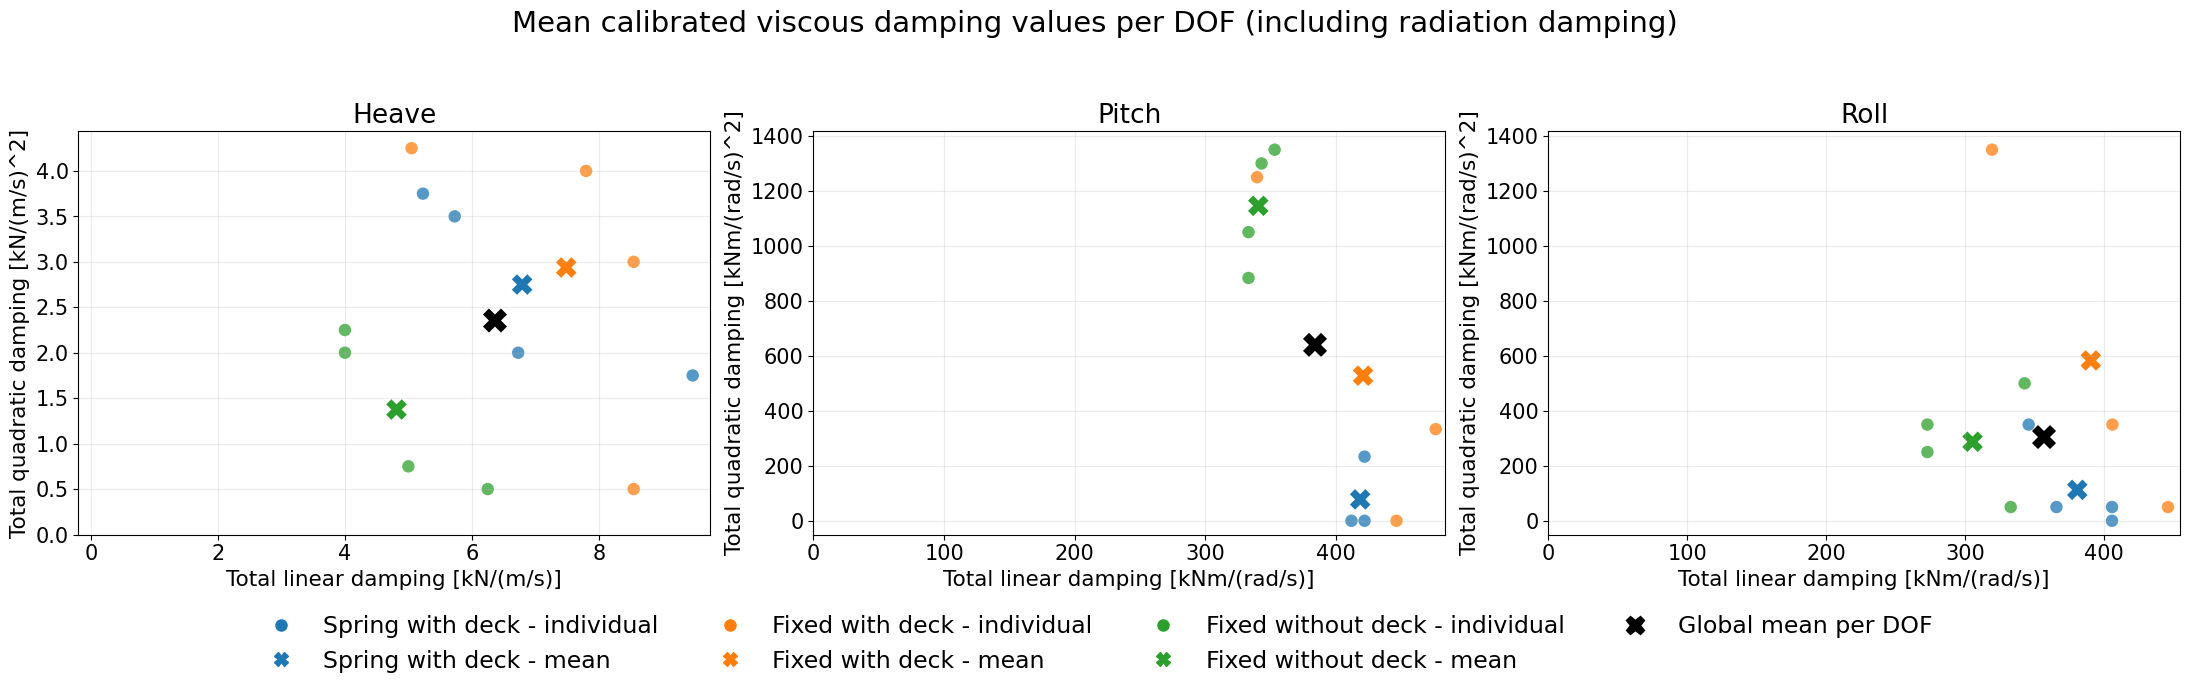

Plot saved to:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\04_total_damping_with_means_all_dofs.png


In [ ]:
# ============================================================
# Plot 4: total damping with mean per construction and global mean per DOF
# ============================================================
# Note: the global total mean uses:
# total linear = global viscous linear + mean radiation damping of the three constructions.
# total quadratic = global viscous quadratic.
plot_all_dofs(
    x_col="total_linear_damping",
    y_col="total_quadratic_damping",
    damping_type="total",
    fig_title="Mean calibrated viscous damping values per DOF (including radiation damping)",
    save_path=plot_total_with_means_path,
    include_means=True,
    mean_x_col="mean_total_linear_damping",
    mean_y_col="mean_total_quadratic_damping",
    global_x_col="total_linear_damping",
    global_y_col="total_quadratic_damping",
)

## Values to copy manually

The cell below prints the global viscous and total damping values per DOF. For total damping, the linear value includes radiation damping according to the method described above.

In [ ]:
# ============================================================
# Useful printout for copying values manually
# ============================================================
for dof in DOF_ORDER:
    row = get_global_row(dof, method="mean_of_all_individual_tests")
    print(f"\n# {DOF_LABELS[dof]} - global damping based on all individual tests")
    print(f"{dof}_viscous_linear_damping = {row['viscous_linear_damping']:.6f}")
    print(f"{dof}_viscous_quadratic_damping = {row['viscous_quadratic_damping']:.6f}")
    print(f"{dof}_total_linear_damping = {row['total_linear_damping']:.6f}")
    print(f"{dof}_total_quadratic_damping = {row['total_quadratic_damping']:.6f}")

print("\n# Viscous damping per construction and DOF")
print("selected_viscous_damping = {")
for dof in DOF_ORDER:
    print(f'    "{dof}": {{')
    for construction in CONSTRUCTION_ORDER:
        row = construction_summary[
            (construction_summary["dof"] == dof)
            & (construction_summary["construction"] == construction)
        ]
        if row.empty:
            continue
        row = row.iloc[0]
        lin = row["mean_viscous_linear_damping"]
        quad = row["mean_viscous_quadratic_damping"]
        print(f'        "{construction}": {{"linear": {lin:.6f}, "quadratic": {quad:.6f}}},  # {CONSTRUCTION_LABELS[construction]}')
    print("    },")
print("}")

print("\n# Total damping per construction and DOF, including radiation damping")
print("selected_total_damping = {")
for dof in DOF_ORDER:
    print(f'    "{dof}": {{')
    for construction in CONSTRUCTION_ORDER:
        row = construction_summary[
            (construction_summary["dof"] == dof)
            & (construction_summary["construction"] == construction)
        ]
        if row.empty:
            continue
        row = row.iloc[0]
        lin = row["mean_total_linear_damping"]
        quad = row["mean_total_quadratic_damping"]
        print(f'        "{construction}": {{"linear": {lin:.6f}, "quadratic": {quad:.6f}}},  # {CONSTRUCTION_LABELS[construction]}')
    print("    },")
print("}")


# Heave - global damping based on all individual tests
heave_viscous_linear_damping = 3.270833
heave_viscous_quadratic_damping = 2.354167
heave_total_linear_damping = 6.364167
heave_total_quadratic_damping = 2.354167

# Pitch - global damping based on all individual tests
pitch_viscous_linear_damping = 248.000000
pitch_viscous_quadratic_damping = 640.000000
pitch_total_linear_damping = 383.790000
pitch_total_quadratic_damping = 640.000000

# Roll - global damping based on all individual tests
roll_viscous_linear_damping = 223.030303
roll_viscous_quadratic_damping = 304.545455
roll_total_linear_damping = 356.870303
roll_total_quadratic_damping = 304.545455

# Viscous damping per construction and DOF
selected_viscous_damping = {
    "heave": {
        "spring": {"linear": 4.562500, "quadratic": 2.750000},  # Spring with deck
        "fixedwith": {"linear": 4.437500, "quadratic": 2.937500},  # Fixed with deck
        "fixedwithout": {"linear": 0.812500, "quadratic": 1.375000},  # Fixed w